In [3]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

In [4]:
load_dotenv()

llm = ChatOpenAI(model='gpt-4o-mini')

In [5]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [9]:
def generate_joke(state: JokeState):
    prompt = f"Generage a joke on the topic {state['topic']}"
    response = llm.invoke(prompt).content

    return{'joke': response}

In [10]:
def explain_joke(state: JokeState):
    prompt = f"Generate an explanation for the following joke. \n {state['joke']}"
    response = llm.invoke(prompt).content

    return{'explanation': response}

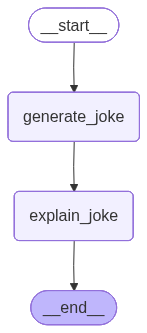

In [11]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('explain_joke', explain_joke)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'explain_joke')
graph.add_edge('explain_joke', END)

# Checkpointer for persistence
checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [12]:
initial_state = {'topic': 'pizza'}

# make a configuration
config1 = {'configurable': {'thread_id': '1'}}
final_state = workflow.invoke(initial_state, config=config1)

In [13]:
final_state

{'topic': 'pizza',
 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough! 🍕",
 'explanation': 'This joke relies on a pun involving the word "dough." In one sense, "dough" refers to the mixture of flour and water used to make pizza crust. In another, more colloquial sense, "dough" is a slang term for money. The humor comes from the play on words: the pizza maker went broke because he wasn\'t able to generate enough money ("dough") to keep his business afloat, while the literal interpretation suggests he wasn\'t able to make enough pizza crust. The dual meaning creates a light-hearted twist, making it a classic example of a pun-based joke.'}

In [18]:
list(workflow.get_state_history(config=config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough! 🍕", 'explanation': 'This joke relies on a pun involving the word "dough." In one sense, "dough" refers to the mixture of flour and water used to make pizza crust. In another, more colloquial sense, "dough" is a slang term for money. The humor comes from the play on words: the pizza maker went broke because he wasn\'t able to generate enough money ("dough") to keep his business afloat, while the literal interpretation suggests he wasn\'t able to make enough pizza crust. The dual meaning creates a light-hearted twist, making it a classic example of a pun-based joke.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f108d4d-ce34-68f0-8002-c54988e936c8'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-02-13T12:09:35.716785+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint

In [19]:
config2 = {'configurable': {'thread_id':'2'}}
workflow.invoke({'topic': 'samosa'}, config=config2)

{'topic': 'samosa',
 'joke': 'Why did the samosa go to school?\n\nBecause it wanted to be a little *filling* in class!',
 'explanation': 'This joke plays on a clever wordplay involving the term "filling." A samosa is a popular savory pastry that is filled with various ingredients like vegetables or meat. In the context of the joke, the phrase "a little filling" has a double meaning. \n\nOn one hand, "filling" refers to the actual contents that make up a samosa. On the other hand, when someone says they want to be "a little filling" in class, it suggests the desire to contribute or participate meaningfully in lessons, akin to being "fulfilling" in an educational context. \n\nThe humor arises from the unexpected personification of the samosa—an inanimate food item wanting to go to school and learn—combined with the pun on the word "filling." The juxtaposition of a samosa’s literal filling with its figurative ambition to contribute to a classroom creates a light-hearted and playful joke.'

In [21]:
list(workflow.get_state_history(config=config2))

[StateSnapshot(values={'topic': 'samosa', 'joke': 'Why did the samosa go to school?\n\nBecause it wanted to be a little *filling* in class!', 'explanation': 'This joke plays on a clever wordplay involving the term "filling." A samosa is a popular savory pastry that is filled with various ingredients like vegetables or meat. In the context of the joke, the phrase "a little filling" has a double meaning. \n\nOn one hand, "filling" refers to the actual contents that make up a samosa. On the other hand, when someone says they want to be "a little filling" in class, it suggests the desire to contribute or participate meaningfully in lessons, akin to being "fulfilling" in an educational context. \n\nThe humor arises from the unexpected personification of the samosa—an inanimate food item wanting to go to school and learn—combined with the pun on the word "filling." The juxtaposition of a samosa’s literal filling with its figurative ambition to contribute to a classroom creates a light-hearte

### **Time Travel**

In [22]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f108d4d-98c8-626b-8000-34d09b5b0b78"}})

{'topic': 'pizza',
 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough!",
 'explanation': 'This joke is a classic play on words that combines a literal meaning with a figurative one. In the context of the joke, "dough" refers to two things: \n\n1. **Pizza Dough**: The raw mixture used to make the base of the pizza. A pizza maker makes dough as part of the process of creating pizzas.\n  \n2. **Money**: "Dough" is also a slang term for money, widely used in informal contexts.\n\nThe punchline plays on the double meaning, suggesting that the pizza maker went broke because he wasn\'t able to generate enough money (dough). This twist creates humor by linking the two meanings in a clever way. The joke rests on the surprise of realizing that "dough" isn\'t just referring to the pizza itself, but rather to financial struggles, giving it a light-hearted, punny twist.'}

In [24]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough!", 'explanation': 'This joke is a classic play on words that combines a literal meaning with a figurative one. In the context of the joke, "dough" refers to two things: \n\n1. **Pizza Dough**: The raw mixture used to make the base of the pizza. A pizza maker makes dough as part of the process of creating pizzas.\n  \n2. **Money**: "Dough" is also a slang term for money, widely used in informal contexts.\n\nThe punchline plays on the double meaning, suggesting that the pizza maker went broke because he wasn\'t able to generate enough money (dough). This twist creates humor by linking the two meanings in a clever way. The joke rests on the surprise of realizing that "dough" isn\'t just referring to the pizza itself, but rather to financial struggles, giving it a light-hearted, punny twist.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns':

### **Update the state**

In [26]:
workflow.update_state({'configurable': {'thread_id':'1', 'checkpoint_id':'1f108d4d-98c8-626b-8000-34d09b5b0b78', 'checkpoint_ns': ""}}, {'topic':'love'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f108d6c-6061-6a85-8001-c3e1f2e1674f'}}

In [27]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'love'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f108d6c-6061-6a85-8001-c3e1f2e1674f'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-02-13T12:23:16.350835+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f108d4d-98c8-626b-8000-34d09b5b0b78'}}, tasks=(PregelTask(id='d8759201-fbfd-e78a-3b07-ef0ea42f0dc9', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza maker go broke?\n\nBecause he just couldn't make enough dough!", 'explanation': 'This joke is a classic play on words that combines a literal meaning with a figurative one. In the context of the joke, "dough" refers to two things: \n\n1. **Pizza Dough**: The raw mixture used to make the base of the pizza. A pizza

In [29]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f108d6c-6061-6a85-8001-c3e1f2e1674f"}})

{'topic': 'love',
 'joke': 'Why did the couple bring a ladder to their date? \n\nBecause they heard love is all about reaching new heights!',
 'explanation': 'This joke plays on the double meaning of the phrase "reaching new heights," which is a common metaphor used to describe the progress and growth in a romantic relationship. In this context, "love is all about reaching new heights" suggests that couples strive to elevate their connection, deepen their emotional bond, and achieve new levels of intimacy.\n\nThe humor comes from the literal interpretation of the couple bringing a ladder to their date. Instead of contemplating the emotional aspects of love, they take the phrase literally and assume they need a physical ladder to achieve those "heights." The absurdity of bringing an actual ladder to a romantic outing creates a playful contrast between the heartfelt sentiment and the couple\'s misguided, yet humorous, action. Thus, the joke elicits a laugh by combining clever wordplay wi

In [30]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'love', 'joke': 'Why did the couple bring a ladder to their date? \n\nBecause they heard love is all about reaching new heights!', 'explanation': 'This joke plays on the double meaning of the phrase "reaching new heights," which is a common metaphor used to describe the progress and growth in a romantic relationship. In this context, "love is all about reaching new heights" suggests that couples strive to elevate their connection, deepen their emotional bond, and achieve new levels of intimacy.\n\nThe humor comes from the literal interpretation of the couple bringing a ladder to their date. Instead of contemplating the emotional aspects of love, they take the phrase literally and assume they need a physical ladder to achieve those "heights." The absurdity of bringing an actual ladder to a romantic outing creates a playful contrast between the heartfelt sentiment and the couple\'s misguided, yet humorous, action. Thus, the joke elicits a laugh by combinin